# Spoken Wiki attentional word recognition pilot task results

In [1]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd
import json
import pickle

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



In [2]:
## Will add columns 'base_str', 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender' from manifests to trial_results where trial_results.stimulus == manifests.base_str

# manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_single_distractor_ground_truth_manifest.pdpkl")
manifests = pd.read_pickle("/om2/user/imgriff/projects/torch_2_aud_attn/swc_prolific_2023_all_condition_ground_truth_manifest.pdpkl")


## Load Model Results 

In [3]:
## import class maps
import pickle
## load WSN vocab mapping 
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
wsn_word_2_class = word_and_speaker_encodings['word_to_idx']
wsn_class_2_word = word_and_speaker_encodings['word_idx_to_word']
cv_word_2_class = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
cv_class_2_word = {v:k for k,v in cv_word_2_class.items()}


In [4]:

# model_names = ["word_task_mono_arch_v07", "word_task_diotic_arch_v07_gend_bal", "word_task_standard_v07", "word_task_half_co_loc_v07",
#              "word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
             

# model_names = ["word_task_standard_v07", "word_task_standard_v07_gend_bal", "word_task_half_co_loc_v07",
#              "word_task_mono_arch_v06", "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
             

# model_names = ["word_task_standard_v07", "word_task_half_co_loc_v07", "word_task_20p_loc_v07_wider_SNR", 'word_task_20p_loc_v07_wider_SNR_residual_attn', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"]
model_names = [ "word_task_25p_loc_v07_LN_last_valid_time_no_affine"]
             
model_name_dict = {"attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor": "Mono WordSpeakerNoise",
                   "word_task_standard_v07_gend_bal": "Binaural CV gend bal no pitch aug.",
                   "word_task_mono_arch_v06": "Mono CommonVoice",
                   "word_task_half_co_loc_v07": "Binaural CV no aug 50% co-located",
                   "word_task_standard_v07": "Binaural CV no pitch augments",
                   "word_task_mono_arch_v07": "Mono CV no pitch augments",
                   "word_task_diotic_arch_v07": "Diotic CV no pitch augments",
                   "word_task_diotic_arch_v07_gend_bal": "Diotic CV gend bal no pitch aug.",
                   "word_task_20p_loc_v07_wider_SNR": "25% co-located wider SNR", # are really 25% co-located
                   "word_task_20p_loc_v07_wider_SNR_residual_attn": "25% co-located wider SNR residual attn", # are really 25% co-located
                   "word_task_25p_loc_v07_LN_last_valid_time_no_affine": "25% co-located LN last valid time no affine"
                  }

all_model_results = []
all_model_f0_results = []

# Convert condition names to  readable format 
test_condition_dict = {'music':"background_musdb18hq",
                    "babble":"background_cv08talkerbabble",
                    "stationary": "background_issnstationary",
                    "modulated": "background_issnfestenplomp",
                    "audioset": "background_audioset",
                    "natural scene": "background_ieeeaaspcasa",
                    "clean": "SILENCE"}
str_to_cond = {v:k for k,v in test_condition_dict.items()}

# update gt manifests to match readable format 
manifests["background_condition"] = manifests.condition.replace(str_to_cond, )

for model_name in model_names:
    output_paths = list(Path(f'cue_duration_eval/{model_name}').glob('*.csv'))
    print(len(output_paths))

    results_dfs = []

    for path in output_paths:
        df = pd.read_csv(path)
        # reformat dict
        df['model'] = path.parent.name
        #parts of name 
        parts = path.stem.split(path.parent.name)[-1].split('_')       
        if "background" in path.stem:
            df['background_condition'] = str_to_cond['_'.join(parts[1:3])]
        else:
            df['background_condition'] = parts[1]
        if 'SILENCE' in path.stem:
            df['background_condition'] = 'clean'
            df['snr'] =  'inf' # really np.inf, 6 for plotting 
        else:
            df['snr'] = int(re.search('(-?\d+)dB', path.stem).group(0).strip('dB'))
        df['cue_dur'] = int(re.search('(-?\d+)ms', path.stem).group(0).strip('ms'))
        results_dfs.append(df)
    model_results = pd.concat(results_dfs, axis=0, ignore_index=True)
    model_str = model_name_dict[model_name]
    model_results['group'] = model_str
    ## Load in model vocab 
    class_2_word =  wsn_class_2_word if 'WordSpeakerNoise' in model_str else  cv_class_2_word
    model_results['pred_word'] = model_results['pred_word_int'].replace(class_2_word)
    model_results['true_word'] = model_results['true_word_int'].replace(class_2_word)


    # Add 1-talker condition metadata to model results
    model_results = pd.merge(model_results,
            manifests[["background_condition", "snr", "word", "word_int", 'target_gender', 'target_f0', 'distractor_f0', 'distractor_gender', 'distractor_word', 'target_transcript', 'distractor_transcript']],
                        left_on=['background_condition', 'snr', "true_word"], right_on=["background_condition", "snr",  "word"], how='left')


    # add confusions 
    model_results['confusions'] = (model_results.pred_word == model_results.distractor_word).astype('int')

    # add adjusted accuracy and confusions 
    target_words = model_results.pred_word.values
    target_transcripts = model_results.target_transcript.values
    distractor_transcripts = model_results.distractor_transcript.values


    adjusted_acc = np.array([int(target_word in target_transcript)
                                if not isinstance(target_transcript, float) else np.nan
                                for target_word, target_transcript in zip(target_words, target_transcripts)
                                ])

    adjusted_confs = np.array([int(target_word in distractor_transcript)
                                if not isinstance(distractor_transcript, float) else np.nan
                                for target_word, distractor_transcript in zip(target_words, distractor_transcripts)
                                ])
    
    model_results['adjusted_accuracy'] = adjusted_acc
    model_results['adjusted_confusions'] = adjusted_confs
    
    all_model_results.append(model_results)

    model_f0_df = model_results[model_results.background_condition.isin([ "1-talker", 'clean'])]
    model_f0_df['gender_cond'] = model_f0_df.apply(lambda row: 'same' if row['target_gender'] == row['distractor_gender'] else 'different', axis=1)
    model_f0_df.loc[model_f0_df.background_condition == 'clean', 'gender_cond'] = 'clean'
    model_f0_df["abs_f0_diff"] = np.abs(model_f0_df.target_f0 - model_f0_df.distractor_f0)
    model_f0_df["percent_f0_diff"] = model_f0_df.distractor_f0 / model_f0_df.target_f0 
    all_model_f0_results.append(model_f0_df)

all_model_results = pd.concat(all_model_results, axis=0, ignore_index=True)
all_model_f0_results = pd.concat(all_model_f0_results, axis=0, ignore_index=True)


all_model_results['sex_cond'] = all_model_results.apply(lambda row: 'Same sex' if row['target_gender'] == row['distractor_gender'] else 'Different sex', axis=1)

all_model_results['cue_dur_s'] = all_model_results['cue_dur'] / 1000

9


In [5]:
all_model_results.loc[all_model_results.snr == np.inf, 'snr'] = 6
all_model_results.loc[all_model_results.snr == 'inf', 'snr'] = 6
all_model_results.snr = all_model_results.snr.astype('int')


In [6]:
all_model_results.model.unique()


array(['word_task_25p_loc_v07_LN_last_valid_time_no_affine'], dtype=object)

In [7]:
all_model_results.cue_dur.unique()

array([1000,  100, 1250, 1500, 1750, 2000,  250,  500,  750])

In [8]:
all_model_results[all_model_results.cue_dur == 2000].accuracy.mean()

0.5611111111111111

## Standard analysis 

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

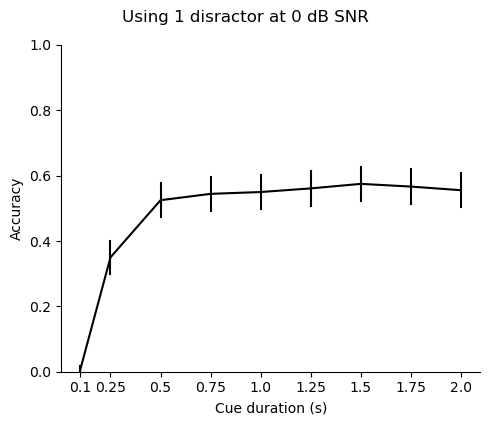

In [11]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = all_model_results[~all_model_results.background_condition.isin(["catch_trial", 'audioset'])]


# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur_s', y='adjusted_accuracy',   #hue_order=hue_order,
                # col_wrap=3,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                err_style='bars', errorbar=('se', 2),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur_s.unique())
g.set_xticklabels(to_plot.cue_dur_s.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()

Text(0.5, 1.05, 'Using 1 disractor at 0 dB SNR')

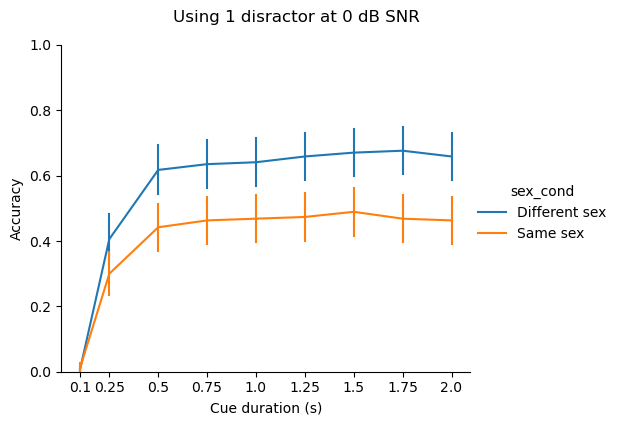

In [12]:
# to_plot = combined[(combined.condition!='audioset') & (combined.snr > -12)]
to_plot = all_model_results[~all_model_results.background_condition.isin(["catch_trial", 'audioset'])]


# add markers to relplot
g = sns.relplot(data=to_plot, x='cue_dur_s', y='adjusted_accuracy',  hue='sex_cond', #hue_order=hue_order,
                # col_wrap=3,
                # style='model', style_order=['human', "attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor"],
                kind='line', marker='',
                color='k',
                height=4, aspect=1.25,
                err_style='bars', errorbar=('se', 2),)

# set labels 
g.set_axis_labels("Cue duration (s)", "Accuracy")
g.set_titles("{col_name}")

# add xtick labels 
g.ax.set_xticks(ticks=to_plot.cue_dur_s.unique())
g.set_xticklabels(to_plot.cue_dur_s.unique())

plt.ylim(0,1)
plt.suptitle(f"Using 1 disractor at 0 dB SNR", y=1.05)
# plt.tight_layout()